In [1]:
# Importing python libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Importing csv
df = pd.read_csv(r"C:\Users\Raffy\Downloads\Compressed\Messy Employee Dataset\Messy_Employee_dataset_Cleaned.csv", delimiter = ';')

In [3]:
# set the theme for the seaborn 
sns.set_theme(style='whitegrid')

In [4]:
# Take a look at the count of rows and columns
df.shape

(1020, 13)

In [5]:
# Take a look at the data type for each column
df.dtypes

Employee_ID           object
First_Name            object
Last_Name             object
Age                    int64
Department            object
Region                object
Status                object
Join_Date             object
Salary               float64
Email                 object
Phone                 object
Performance_Score      int64
Remote_Work            int64
dtype: object

In [6]:
# Take a look at the general aggregate of the numeric column
df.describe()

,Age,Salary,Performance_Score,Remote_Work
count,1020.00000,1020.000000,1020.000000,1020.000000
mean,32.00000,85042.916951,2.576471,0.502941
std,5.15415,19651.591056,1.091962,0.500237
min,25.00000,50047.320000,1.000000,0.000000
25%,30.00000,68811.232500,2.000000,0.000000
50%,30.00000,84711.750000,3.000000,1.000000
75%,35.00000,100372.662500,4.000000,1.000000
max,40.00000,119971.650000,4.000000,1.000000


In [7]:
# Check if there's any null value
df.isna().sum()

Employee_ID          0
First_Name           0
Last_Name            0
Age                  0
Department           0
Region               0
Status               0
Join_Date            0
Salary               0
Email                0
Phone                0
Performance_Score    0
Remote_Work          0
dtype: int64

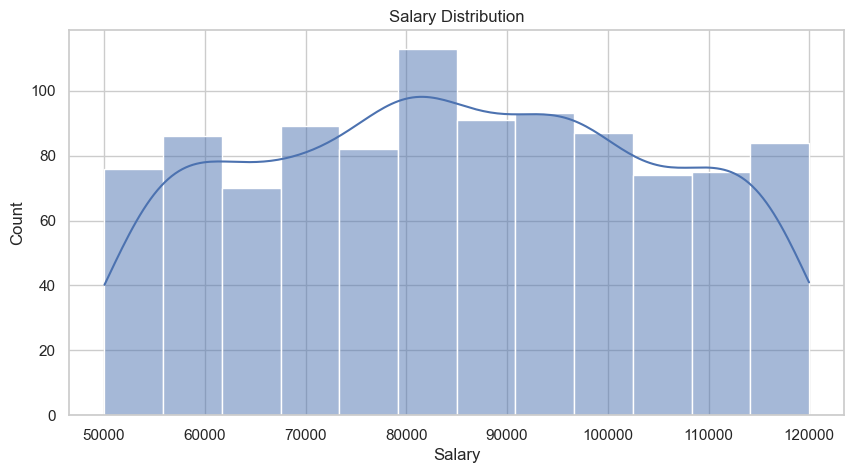

In [8]:
# Salary Distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='Salary', kde=True)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.show()

Insight:The salary distribution appears to be approximately normal (bell-shaped). Most employees earn between 80,000 - 90,000, which represents the peak of the distribution. No significant outliers were detected on either end.

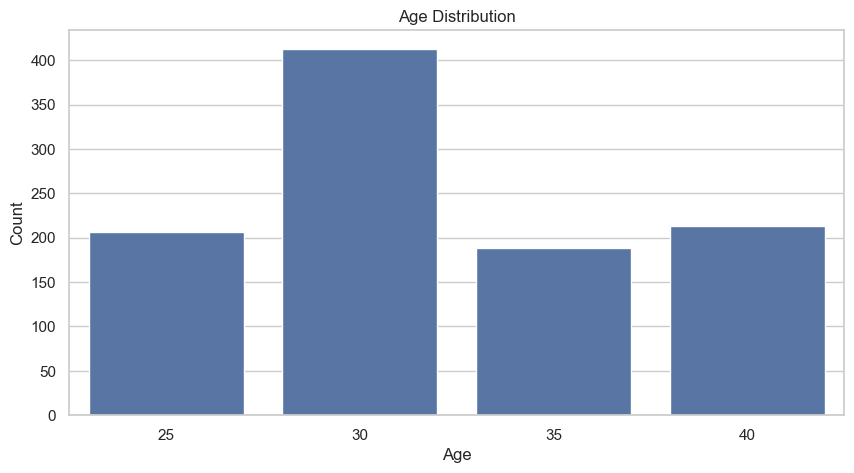

In [9]:
# Age Distibution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Age', order=[25,30,35,40])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

Insight: The Age distribution appear to be right skewed, with majority of employee aged 30, The company workforce is relatively young, with fewer employees in the 35-40 age range. No significant outliers were detected on either end.

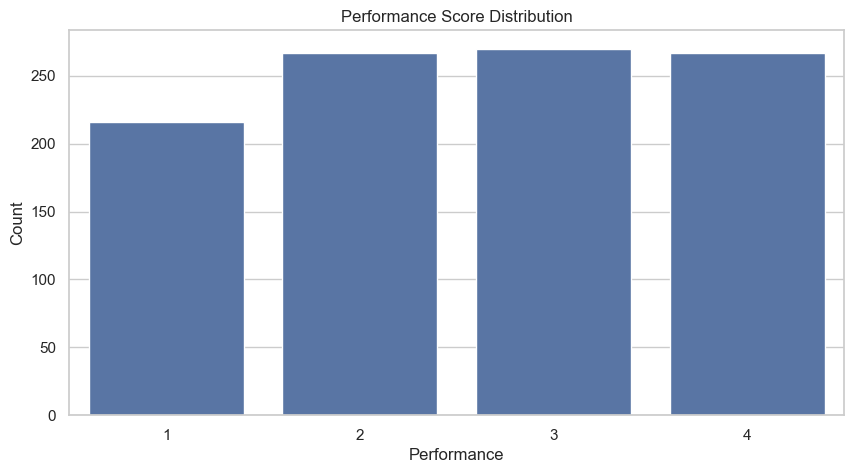

In [10]:
# Performance Score Distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Performance_Score', order=[1,2,3,4])
plt.title('Performance Score Distribution')
plt.xlabel('Performance')
plt.ylabel('Count')
plt.show()

Insight: The majority of employees score 3 out of 4, suggesting that most employees are performing above average. Very few employees fall at the lowest score of 1, indicating that poor performance is uncommon in this organization.

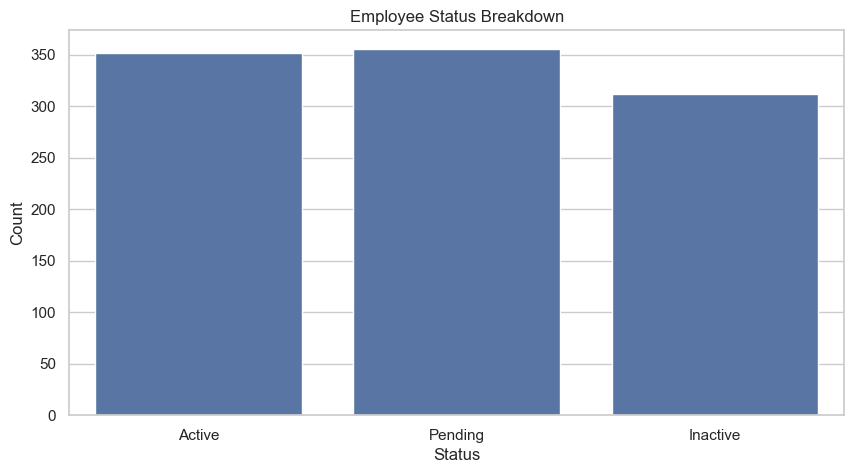

In [11]:
# Employee Status Distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='Status')
plt.title('Employee Status Breakdown')
plt.xlabel('Status')
plt.ylabel('Count')
plt.show()

Insight: The majority of employee in this organization have an Pending status, followed by Active and Inactive. The high number of Pending employees may suggest a recent surge in hiring or a slow onboarding process. The relatively low Inactive count indicates decent overall retention.

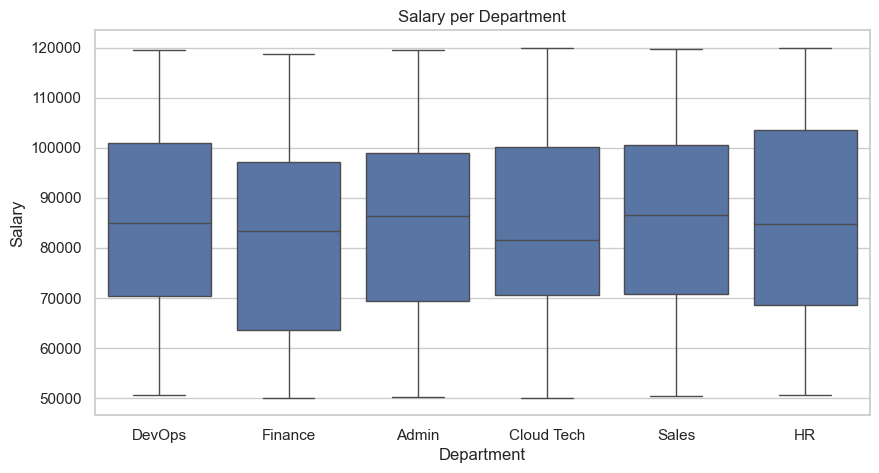

In [12]:
# Salary per Department
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Department', y='Salary')
plt.title('Salary per Department')
plt.xlabel('Department')
plt.ylabel('Salary')
plt.show()

Insight: HR department has the highest median salary, while Finance has the lowest median which is surprising given that Finance roles are typically among the higher paid in most organizations. Most departments show similar median salaries suggesting standardized pay across the company. DevOps and Finance show the widest salary spread, indicating a larger pay gap between employees within those departments.

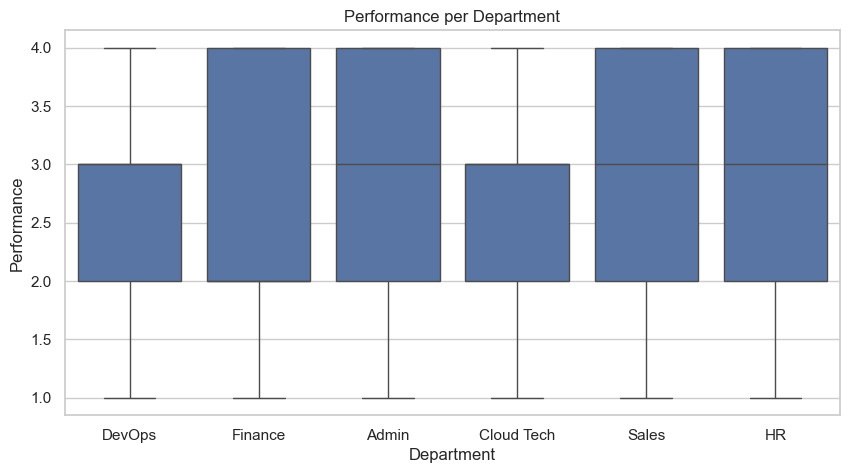

In [13]:
# Performance per Department
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Department', y='Performance_Score')
plt.title('Performance per Department')
plt.xlabel('Department')
plt.ylabel('Performance')
plt.show()

Insight: Most departments share a similar median performance score of 3, suggesting consistent performance across the organization. Cloud Tech shows the lowest median performance score, indicating it may need more support or management attention. All departments range from score 1 to 4, showing that every department has both high and low performers regardless of the median.

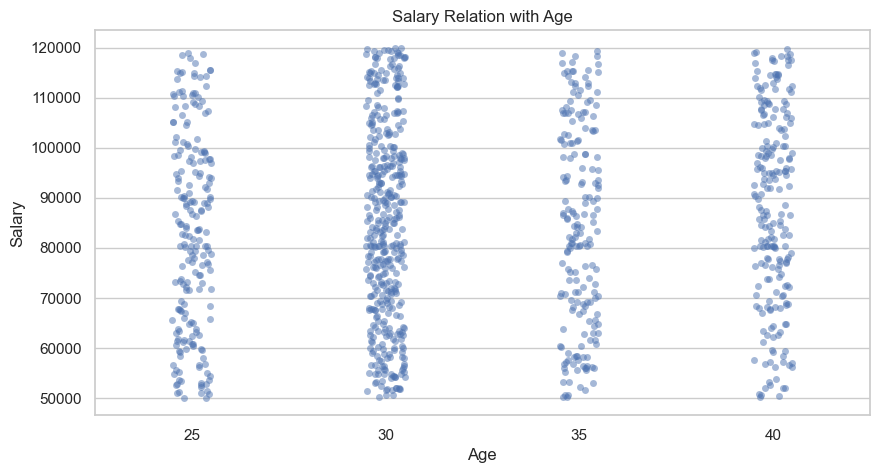

In [14]:
# Salary Relation With Age
plt.figure(figsize=(10,5))
sns.stripplot(data=df, x='Age', y='Salary',jitter=True, alpha=0.5)
plt.title('Salary Relation with Age')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.show()

Insight: There is no clear relationship between age and salary. Employees across all age groups (25, 30, 35, 40) show a similar salary range of 50,000 - 120,000, suggesting that age is not a determining factor for salary in this organization. Compensation is likely driven by other factors such as department or performance instead.

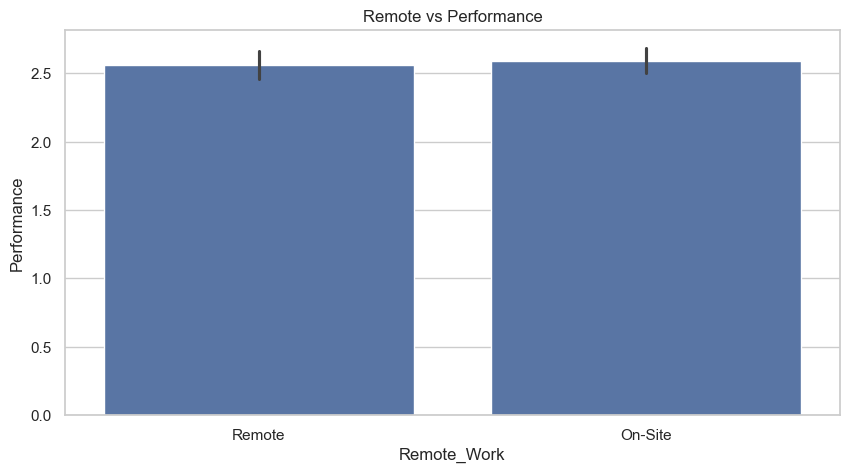

In [15]:
# Work Performance based on Remote
plt.figure(figsize=(10,5))
sns.barplot(data=df, x='Remote_Work', y='Performance_Score')
plt.title('Remote vs Performance')
plt.xlabel('Remote_Work')
plt.xticks([0,1], ['Remote','On-Site'])
plt.ylabel('Performance')
plt.show()

Insight: Remote and on-site employees show nearly identical average performance scores of around 2.5, suggesting that work location has no significant impact on employee performance. This implies the organization could confidently expand remote work policies without expecting a decline in overall performance.

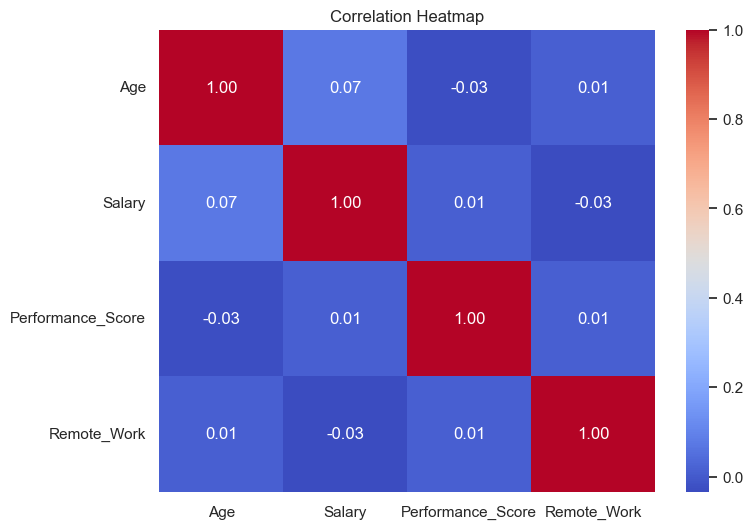

In [16]:
# Correlation Heatmap
numerical_cols = df[['Age','Salary','Performance_Score','Remote_Work']]
numerical_corr = numerical_cols.corr()
plt.figure(figsize=(8,6))
sns.heatmap(data=numerical_corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Insight: The correlation heatmap reveals that there is no significant correlation between Age, Salary, Performance Score, and Remote Work. The highest correlation is between Age and Salary at only 0.07, which is still extremely weak. This suggests that in this organization, salary is not determined by age, and remote work does not influence performance. HR and management should look beyond these factors when making compensation and performance decisions.

([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'DevOps'),
  Text(1, 0, 'Finance'),
  Text(2, 0, 'Admin'),
  Text(3, 0, 'Cloud Tech'),
  Text(4, 0, 'Sales'),
  Text(5, 0, 'HR')])

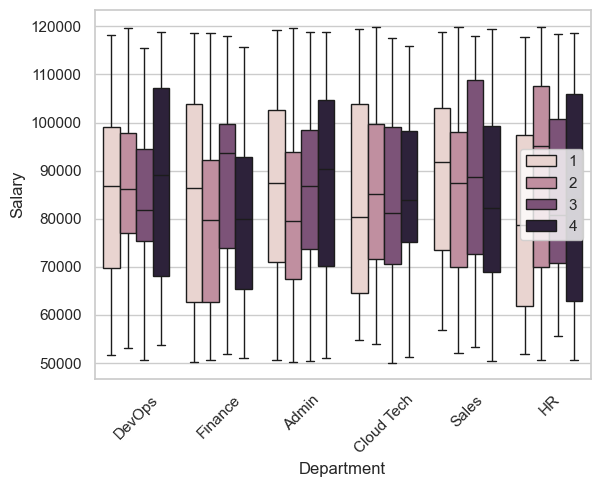

In [17]:
# Department, Salary, and Performance Correlation
sns.boxplot(data=df, x='Department', y='Salary', hue='Performance_Score')
plt.legend()
plt.xticks(rotation=45)

Insight: Across most departments, there is no clear pattern between performance score and salary. High performers (score 4) do not consistently earn more than low performers (score 1), suggesting that salary is not strongly tied to performance in this organization. This could be a concern for retention, as top performers may feel underrewarded compared to their lower performing peers.

## Key Findings & Summary

### Dataset Overview
- 1,020 employees across 6 departments and 6 regions
- Salary ranges from 50,000 to 120,000

### Findings

**1. Salary Distribution**
The salary distribution is approximately normal with most employees 
earning between 80,000 - 90,000. No significant outliers detected, 
suggesting standardized pay across the organization.

**2. Workforce Demographics**
The workforce is relatively young, skewed towards employees aged 30. 
Fewer employees fall in the 35-40 age range.

**3. Performance**
Most employees score 3 out of 4, indicating above average performance 
across the organization. Cloud Tech has the lowest median performance 
and may need additional support.

**4. Employee Retention**
The majority of employees are Active, with a notable number of Pending 
employees suggesting recent hiring activity or slow onboarding.

**5. Salary vs Department**
HR has the highest median salary while Finance has the lowest, which 
is unexpected for a Finance department. Salaries are fairly similar 
across departments overall.

**6. Remote Work vs Performance**
Remote and on-site employees perform almost identically, suggesting 
the organization can expand remote work policies without risking 
performance decline.

**7. Correlation Analysis**
No significant correlation exists between Age, Salary, Performance 
Score, and Remote Work. Salary decisions appear to be independent 
of age and performance, which may affect long term retention of 
top performers.